Binary Image Matrix:

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


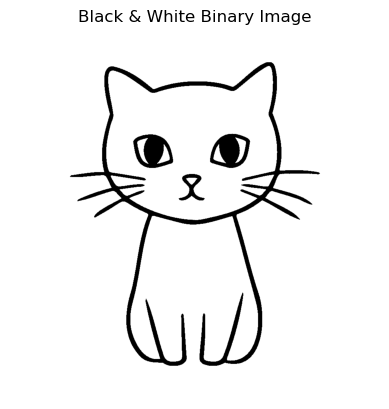

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Load the image
image_path = r"C:\\Users\\soumy\\Downloads\\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"
img = Image.open(image_path)

# Step 2: Convert to grayscale
gray = img.convert("L")

# Step 3: Convert to numpy array
img_array = np.array(gray)

# Step 4: Convert to binary (black = 0, white = 1)
binary_image = np.where(img_array > 128, 1, 0)

# Step 5: Print matrix
print("Binary Image Matrix:\n")
print(binary_image)

# Step 6: Display the binary image
plt.imshow(binary_image, cmap='gray')
plt.title("Black & White Binary Image")
plt.axis("off")
plt.show()


Binary Image Matrix:

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


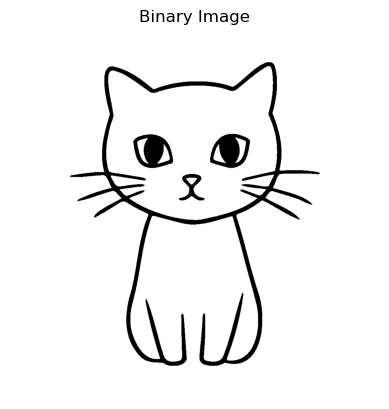

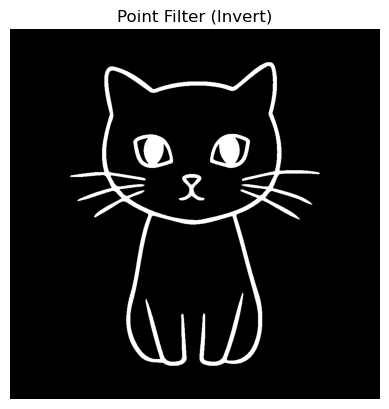

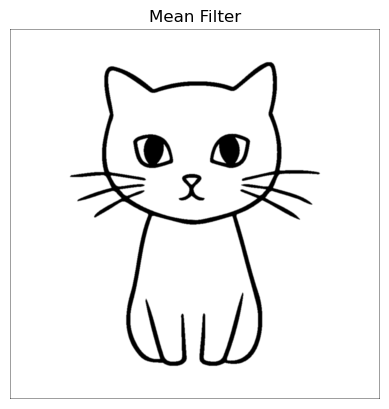

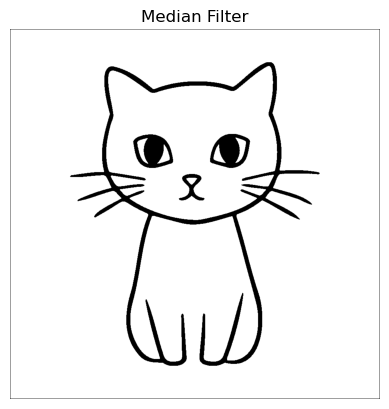

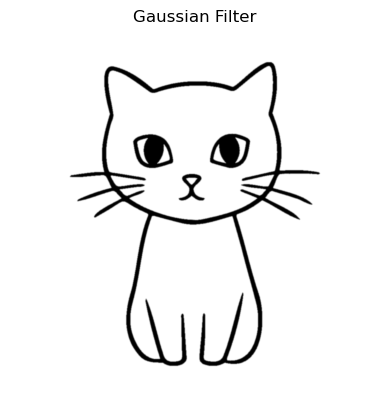

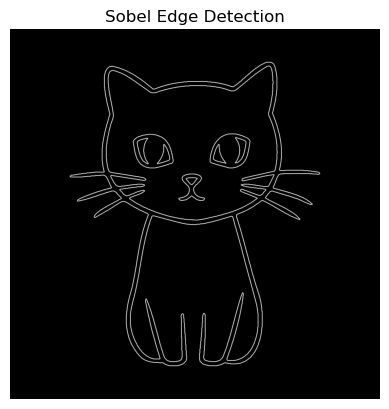

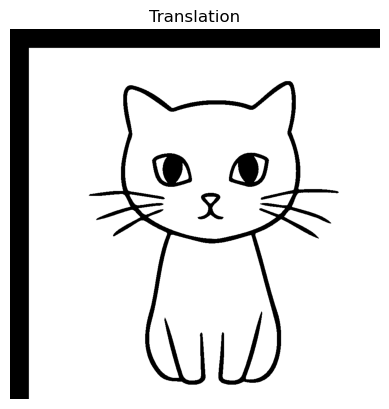

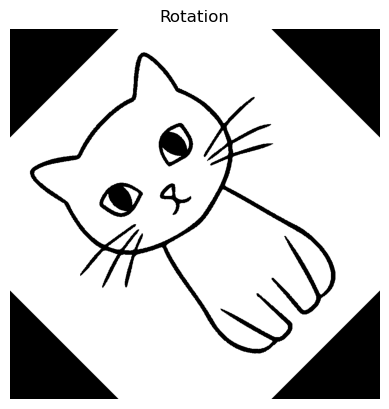

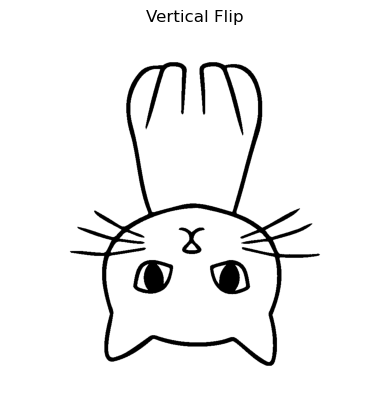

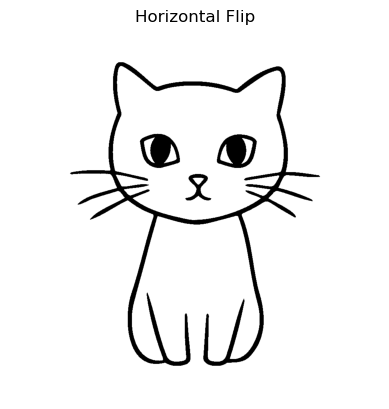

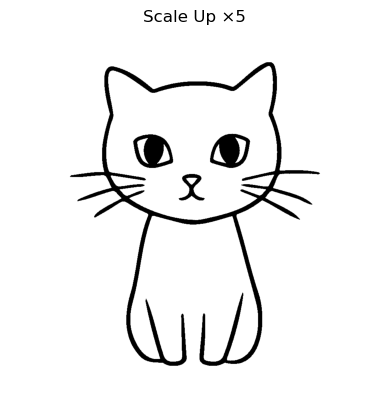

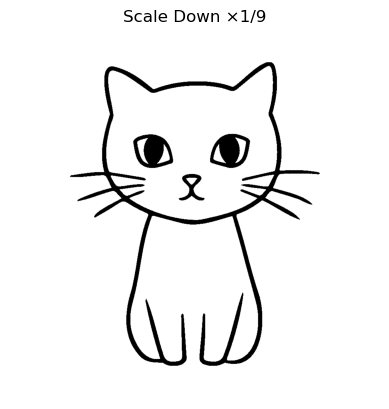

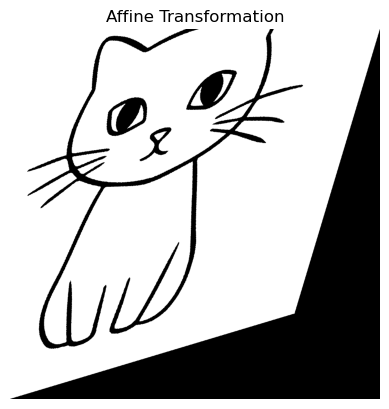

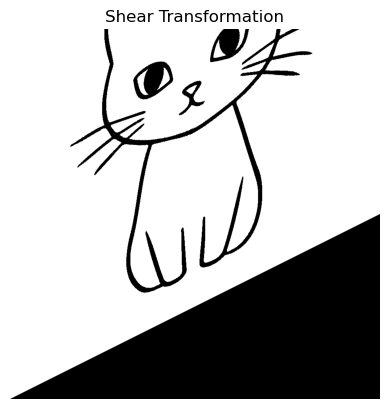

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import rotate, affine_transform, gaussian_filter, sobel

class ImageTransformation:

    def __init__(self, image_path):

        img = Image.open(image_path)
        gray = img.convert("L")

        self.image = np.array(gray)

        # Convert to binary
        self.binary = np.where(self.image > 128, 1, 0)

        print("Binary Image Matrix:\n")
        print(self.binary)

        plt.imshow(self.binary, cmap='gray')
        plt.title("Binary Image")
        plt.axis("off")
        plt.show()

    # ---------------- POINT FILTER ----------------
    def point_filter(self):
        inverted = 1 - self.binary

        plt.imshow(inverted, cmap='gray')
        plt.title("Point Filter (Invert)")
        plt.axis("off")
        plt.show()

    # ---------------- MEAN FILTER ----------------
    def mean_filter(self):

        result = np.zeros_like(self.binary, dtype=float)

        for i in range(1, self.binary.shape[0]-1):
            for j in range(1, self.binary.shape[1]-1):

                neighborhood = self.binary[i-1:i+2, j-1:j+2]
                result[i,j] = np.mean(neighborhood)

        plt.imshow(result, cmap='gray')
        plt.title("Mean Filter")
        plt.axis("off")
        plt.show()

    # ---------------- MEDIAN FILTER ----------------
    def median_filter(self):

        result = np.zeros_like(self.binary)

        for i in range(1, self.binary.shape[0]-1):
            for j in range(1, self.binary.shape[1]-1):

                neighborhood = self.binary[i-1:i+2, j-1:j+2]
                result[i,j] = np.median(neighborhood)

        plt.imshow(result, cmap='gray')
        plt.title("Median Filter")
        plt.axis("off")
        plt.show()

    # ---------------- GAUSSIAN FILTER ----------------
    def gaussian_filter(self):

        result = gaussian_filter(self.binary.astype(float), sigma=1)

        plt.imshow(result, cmap='gray')
        plt.title("Gaussian Filter")
        plt.axis("off")
        plt.show()

    # ---------------- SOBEL FILTER ----------------
    def sobel_filter(self):

        sx = sobel(self.binary, axis=0)
        sy = sobel(self.binary, axis=1)

        sobel_img = np.hypot(sx, sy)

        plt.imshow(sobel_img, cmap='gray')
        plt.title("Sobel Edge Detection")
        plt.axis("off")
        plt.show()

    # ---------------- TRANSLATION ----------------
    def translation(self, tx=50, ty=50):

        translated = np.zeros_like(self.binary)

        rows, cols = self.binary.shape

        for i in range(rows):
            for j in range(cols):

                if i+tx < rows and j+ty < cols:
                    translated[i+tx, j+ty] = self.binary[i,j]

        plt.imshow(translated, cmap='gray')
        plt.title("Translation")
        plt.axis("off")
        plt.show()

    # ---------------- ROTATION ----------------
    def rotation(self, angle=45):

        rotated = rotate(self.binary, angle, reshape=False)

        plt.imshow(rotated, cmap='gray')
        plt.title("Rotation")
        plt.axis("off")
        plt.show()

    # ---------------- VERTICAL FLIP ----------------
    def vertical_flip(self):

        flipped = np.flipud(self.binary)

        plt.imshow(flipped, cmap='gray')
        plt.title("Vertical Flip")
        plt.axis("off")
        plt.show()

    # ---------------- HORIZONTAL FLIP ----------------
    def horizontal_flip(self):

        flipped = np.fliplr(self.binary)

        plt.imshow(flipped, cmap='gray')
        plt.title("Horizontal Flip")
        plt.axis("off")
        plt.show()

    # ---------------- SCALE UP ----------------
    def scale_up(self):

        scaled = self.binary * 5

        plt.imshow(scaled, cmap='gray')
        plt.title("Scale Up ×5")
        plt.axis("off")
        plt.show()

    # ---------------- SCALE DOWN ----------------
    def scale_down(self):

        scaled = self.binary * (1/9)

        plt.imshow(scaled, cmap='gray')
        plt.title("Scale Down ×1/9")
        plt.axis("off")
        plt.show()

    # ---------------- AFFINE TRANSFORMATION ----------------
    def affine(self):

        matrix = np.array([[1,0.3],[0.3,1]])

        affine_img = affine_transform(self.binary, matrix)

        plt.imshow(affine_img, cmap='gray')
        plt.title("Affine Transformation")
        plt.axis("off")
        plt.show()

    # ---------------- SHEAR ----------------
    def shear(self):

        shear_matrix = np.array([[1,0.5],[0,1]])

        shear_img = affine_transform(self.binary, shear_matrix)

        plt.imshow(shear_img, cmap='gray')
        plt.title("Shear Transformation")
        plt.axis("off")
        plt.show()


# ---------------- MAIN PROGRAM ----------------

image_path = r"C:\\Users\\soumy\\Downloads\\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

img = ImageTransformation(image_path)

img.point_filter()
img.mean_filter()
img.median_filter()
img.gaussian_filter()
img.sobel_filter()

img.translation()
img.rotation()
img.vertical_flip()
img.horizontal_flip()

img.scale_up()
img.scale_down()

img.affine()
img.shear()
